# Miami-Dade Lifestyle Preference Analysis

## Project Objective

The objective of this project is to analyze lifestyle preference trends among adults aged 30–35 in Miami-Dade County.This data was obtained from enjoyable surveys that were displayed through ads on social media & google browser.

The analysis compares five lifestyle categories:

- Fitness
- Beach
- Day Weekend Activities
- Trips Outside Miami
- Nightlife

The goal is to identify which lifestyle niches could represent stronger opportunities for a future niche-based social connection app.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
np.random.seed(42)

n = 1000

categories = [
    "Fitness",
    "Beach",
    "Day Weekend Activities",
    "Trips Outside Miami",
    "Nightlife"
]

probabilities = [0.32, 0.25, 0.19, 0.14, 0.10]

df = pd.DataFrame({
    "respondent_id": range(1, n + 1),
    "age": np.random.randint(30, 36, n),
    "county": ["Miami-Dade County"] * n,
    "primary_preference": np.random.choice(categories, n, p=probabilities),
    "app_interest": np.random.choice(
        ["High", "Medium", "Low"],
        n,
        p=[0.55, 0.30, 0.15]
    ),
    "weekend_preference": np.random.choice(
        ["Daytime", "Nighttime", "Both"],
        n,
        p=[0.50, 0.20, 0.30]
    ),
    "monthly_activity_budget": np.random.randint(80, 401, n)
})

df.head()

,respondent_id,age,county,primary_preference,app_interest,weekend_preference,monthly_activity_budget
0,1,33,Miami-Dade County,Fitness,Low,Nighttime,392
1,2,34,Miami-Dade County,Fitness,Low,Daytime,387
2,3,32,Miami-Dade County,Fitness,High,Daytime,216
3,4,34,Miami-Dade County,Fitness,Low,Nighttime,261
4,5,34,Miami-Dade County,Fitness,High,Both,80


In [3]:
print(f"Total rows: {df.shape[0]}")
print(f"Total columns: {df.shape[1]}")

Total rows: 1000
Total columns: 7


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   respondent_id            1000 non-null   int64 
 1   age                      1000 non-null   int32 
 2   county                   1000 non-null   object
 3   primary_preference       1000 non-null   object
 4   app_interest             1000 non-null   object
 5   weekend_preference       1000 non-null   object
 6   monthly_activity_budget  1000 non-null   int32 
dtypes: int32(2), int64(1), object(4)
memory usage: 47.0+ KB


## Dataset Overview

The dataset contains 1,000 synthetic survey responses from adults aged 30–35 in Miami-Dade County.

Each row represents one survey response. The dataset includes demographic information, lifestyle preference, app interest level, weekend preference, and estimated monthly activity budget.

## Preference Analysis

This section analyzes the distribution of lifestyle preferences among survey responses.

In [5]:
preference_summary = (
    df["primary_preference"]
    .value_counts()
    .reset_index()
)

preference_summary.columns = ["activity_category", "response_count"]

preference_summary["preference_share"] = (
    preference_summary["response_count"] / len(df) * 100
).round(2)

preference_summary

,activity_category,response_count,preference_share
0,Fitness,322,32.2
1,Beach,239,23.9
2,Day Weekend Activities,198,19.8
3,Trips Outside Miami,143,14.3
4,Nightlife,98,9.8


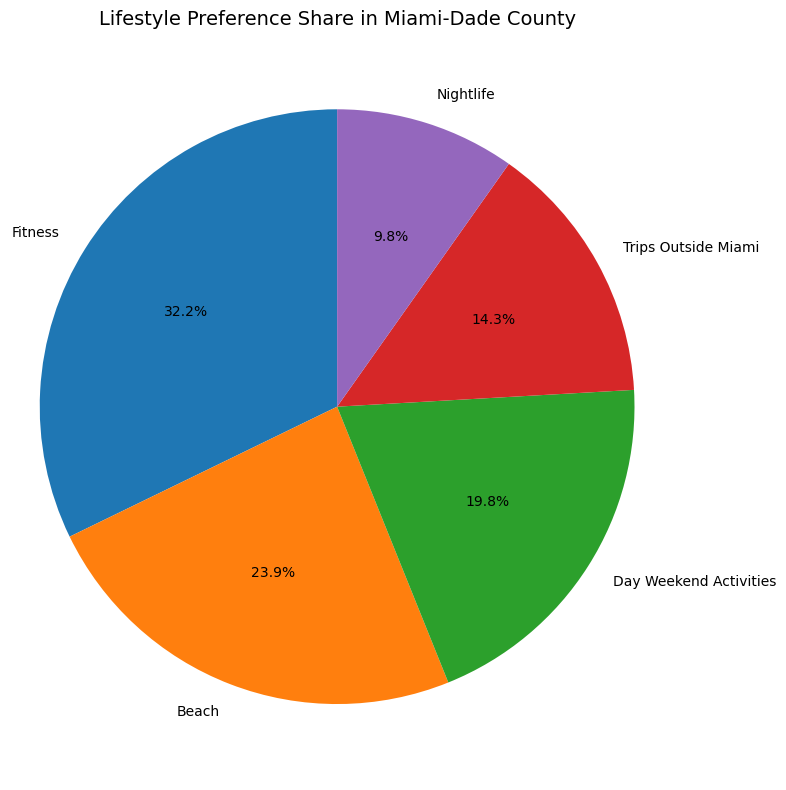

In [6]:
plt.figure(figsize=(8, 8))

plt.pie(
    preference_summary["preference_share"],
    labels=preference_summary["activity_category"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Lifestyle Preference Share in Miami-Dade County", fontsize=14)
plt.axis("equal")
plt.tight_layout()

plt.savefig("../charts/preference_pie_chart.png")
plt.show()

## Preference Share Interpretation

The pie chart shows the distribution of lifestyle preferences among adults aged 30–35 in Miami-Dade County.

Fitness represents the largest share of preferences, followed by Beach activities and Day Weekend Activities. Trips Outside Miami and Nightlife represent smaller shares of responses.

This suggests that a future niche-based social connection app may have stronger initial positioning around wellness, beach lifestyle, and daytime social experiences.

## Preference Ranking Interpretation

Fitness ranked as the strongest lifestyle preference among the simulated respondents, followed by Beach activities and Day Weekend Activities.

This suggests that adults aged 30–35 in Miami-Dade County may respond better to lifestyle-based social experiences connected to wellness, outdoor activities, and daytime social plans.

Nightlife ranked as the lowest preference category.

In [7]:
app_interest_summary = pd.crosstab(
    df["primary_preference"],
    df["app_interest"],
    normalize="index"
).mul(100).round(2)

app_interest_summary

app_interest,High,Low,Medium
primary_preference,,,
Beach,54.81,15.48,29.71
Day Weekend Activities,58.08,14.65,27.27
Fitness,55.59,12.42,31.99
Nightlife,48.98,16.33,34.69
Trips Outside Miami,53.85,14.69,31.47


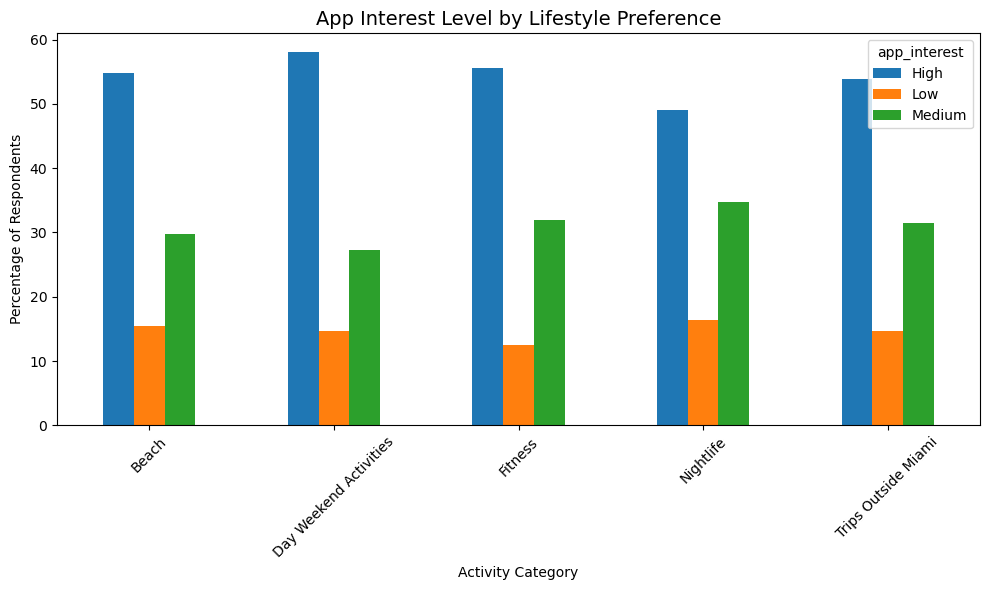

In [8]:
app_interest_summary.plot(kind="bar", figsize=(10, 6))

plt.title("App Interest Level by Lifestyle Preference", fontsize=14)
plt.xlabel("Activity Category")
plt.ylabel("Percentage of Respondents")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("../charts/app_interest_by_category.png")
plt.show()

In [9]:
budget_summary = (
    df.groupby("primary_preference")["monthly_activity_budget"]
    .mean()
    .round(2)
    .sort_values(ascending=False)
    .reset_index()
)

budget_summary.columns = ["activity_category", "average_monthly_budget"]

budget_summary

,activity_category,average_monthly_budget
0,Nightlife,254.08
1,Trips Outside Miami,247.51
2,Beach,246.49
3,Day Weekend Activities,242.90
4,Fitness,230.96


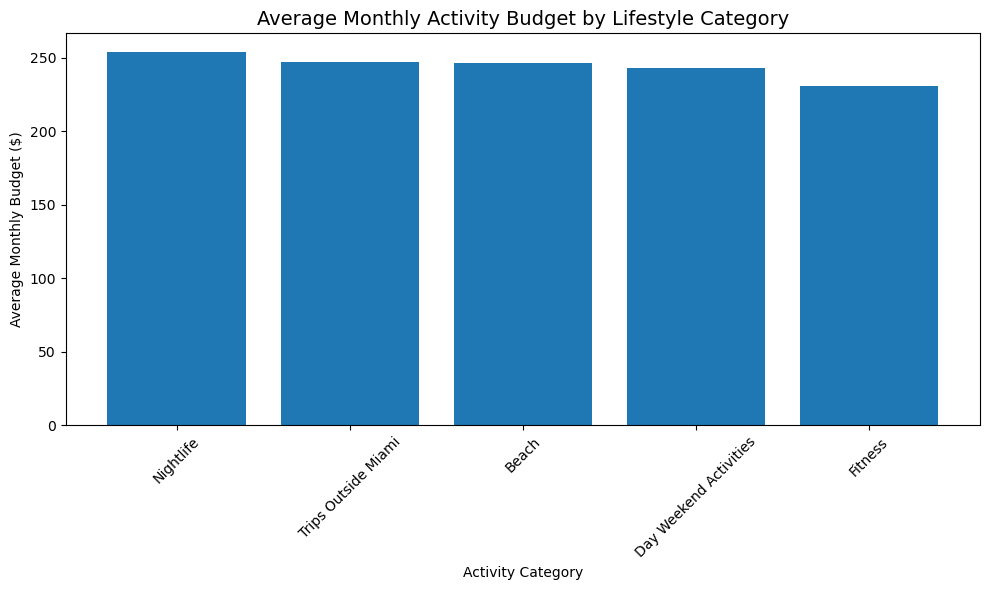

In [10]:
plt.figure(figsize=(10, 6))

plt.bar(
    budget_summary["activity_category"],
    budget_summary["average_monthly_budget"]
)

plt.title("Average Monthly Activity Budget by Lifestyle Category", fontsize=14)
plt.xlabel("Activity Category")
plt.ylabel("Average Monthly Budget ($)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("../charts/budget_by_category.png")
plt.show()

In [11]:
df.to_csv("../data/miami_lifestyle_synthetic_survey.csv", index=False)

## Key Findings

1. Fitness ranked as the strongest preference category among the simulated respondents.
2. Beach activities ranked second, showing strong interest in outdoor and lifestyle-based social experiences.
3. Day Weekend Activities ranked third, suggesting potential demand for daytime social plans such as restaurants, museums, brunch, and cultural activities.
4. Trips Outside Miami ranked fourth, showing moderate interest in short-distance travel and weekend escapes.
5. Nightlife ranked last, suggesting that this audience may be less focused on party-centered social experiences compared to wellness, beach, and daytime activities.

## Business Recommendation

Based on the preference ranking, a future niche-based social connection app targeting adults aged 30–35 in Miami-Dade County should prioritize Fitness, Beach, and Day Weekend Activities as the first core communities.

A strong initial product strategy could focus on helping users connect through fitness groups, beach activities, brunch plans, daytime restaurant meetups, museum visits, cultural activities, and short weekend trips outside Miami.

Nightlife could be included as a secondary category, but it should not be the main positioning of the app based on this analysis.

## Disclaimer

All information in this analysis was provided by a third party responsible for data collection via interactive advertisements.

The content consists of statistics derived from that data; the recommendations and conclusions presented are based on information provided by the data contributor, and no specific results or definitive facts are guaranteed.

Any actions taken based on this analysis are the sole and exclusive responsibility of the person taking such action.